# Tutorial 20 - extract_ocv_dva_ica

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

## Step 1: extract_ocv_dva_ica

D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\extract\dva_ica.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dva_ica["dV_dQ"] = dv_dq
D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\extract\dva_ica.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dva_ica["dQ_dV"] = 1 / df_dva_ica["dV_dQ"]
D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\extract\dva_ica.py:182: SettingWithCopyWarning: 
A value is trying to be set on a cop

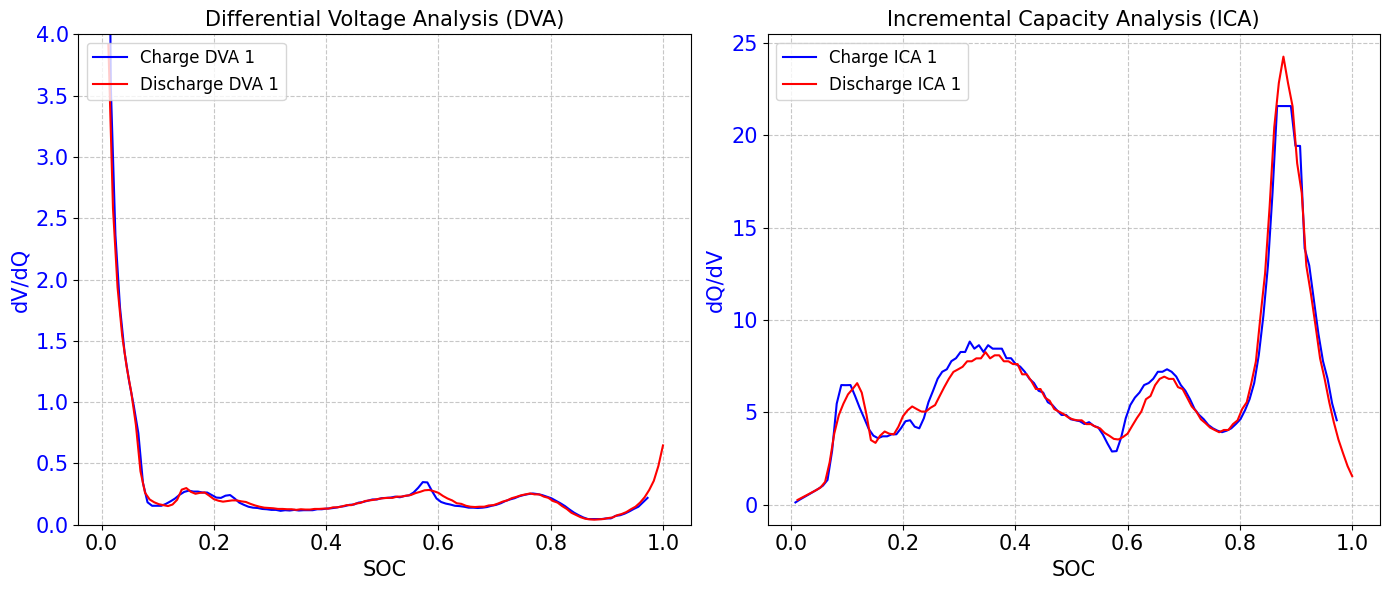

In [4]:
dva_ica_data = eet.extract_ocv_dva_ica(
    df=standardized_data,
    soc_c_ref=4.75,
    visualize=True,
)

In [5]:
dva_ica_data[["dV_dQ", "dQ_dV"]].head(6)

,dV_dQ,dQ_dV
0,NaN,NaN
1,0.646906,1.545819
2,0.479381,2.086023
3,0.358246,2.791375
4,0.283503,3.527298
5,0.224226,4.459786


## Step 2: With Savitzky-Golay smoothing

In [6]:
dva_ica_data_sg = eet.extract_ocv_dva_ica(
    df=standardized_data,
    soc_c_ref=4.75,
    savgol=True,
    visualize=True,
)

D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\extract\dva_ica.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dva_ica["dV_dQ"] = dv_dq
D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\extract\dva_ica.py:172: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dva_ica["dQ_dV"] = 1 / df_dva_ica["dV_dQ"]


ValueError: array must not contain infs or NaNs

In [ ]:
dva_ica_data_sg[["dV_dQ", "dQ_dV"]].head(6)